# End-to-End: Vision Engine → Geometry Engine

Notebook chạy một ảnh thật qua luồng hiện tại:

```text
Ảnh BGR
  → vision_engine: RF-DETR + YOLO person segmentation + Depth Anything V3
  → FramePipelineResult
  → geometry_engine: person point/depth + load representative depth
```

Model được lazy-load và cache trong cùng một `ModelManager`. Gọi `vision_pipeline.process()` cho ảnh tiếp theo bằng cùng manager sẽ tái sử dụng model đã load. Relative depth không phải khoảng cách theo mét.

In [1]:
from __future__ import annotations

import sys
from dataclasses import asdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
PACKAGES_DIR = PROJECT_ROOT / 'backend' / 'packages'
if not PACKAGES_DIR.is_dir():
    raise RuntimeError('Run from the project root or notebooks directory')
if str(PACKAGES_DIR) not in sys.path:
    sys.path.insert(0, str(PACKAGES_DIR))

from geometry_engine import (
    estimate_person_representative,
    load_geometry_config,
    load_representative_depth,
)
from vision_engine import OfflineFramePipeline, build_model_manager
from vision_engine.frame_pipeline import render_detection_preview

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\crane-load-warning


## 1. Chọn input và đọc cấu hình

Mặc định dùng ảnh mẫu và model config có sẵn trong repo. Đổi `IMAGE_PATH` nếu muốn chạy ảnh khác.

In [2]:
IMAGE_PATH = PROJECT_ROOT / 'data' / 'samples' / '10.png'
MODELS_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'models.local.yaml'
GEOMETRY_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'geometry.local.yaml '

for required_path in (IMAGE_PATH, MODELS_CONFIG_PATH, GEOMETRY_CONFIG_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

with MODELS_CONFIG_PATH.open('r', encoding='utf-8') as stream:
    models_payload = yaml.safe_load(stream)
if not isinstance(models_payload, dict):
    raise TypeError('models config root must be a YAML mapping')

geometry_config = load_geometry_config(GEOMETRY_CONFIG_PATH)
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise ValueError(f'OpenCV could not decode: {IMAGE_PATH}')

print(f'Image: {IMAGE_PATH.name}, shape={image_bgr.shape}')
geometry_config

Image: 10.png, shape=(768, 1376, 3)


GeometryConfig(representative_depth=RepresentativeDepthConfig(person_bottom_fraction=0.1, minimum_valid_pixels=5, load_inner_inset_fraction=0.15), load_anchors=LoadAnchorsConfig(patch_size=9, patch_stride=4, seed_depth_tolerance=0.1, minimum_valid_patch_fraction=0.5), connected_region=ConnectedRegionConfig(neighbor_radius=1, seed_depth_tolerance=0.1, local_neighbor_depth_tolerance=0.05), farthest_point_sampling=FarthestPointSamplingConfig(maximum_anchors=16, minimum_distance=0.0), pseudo_bev=PseudoBEVConfig(lateral_scale=1.0, longitudinal_scale=1.0, minimum_depth=1e-06), zones=ZonesConfig(danger=ZoneBufferConfig(lateral=0.15, longitudinal=0.2), warning=ZoneBufferConfig(lateral=0.3, longitudinal=0.4)))

## 2. Khởi tạo pipeline

Cell này chỉ đăng ký model factories. Model thật được load ở lần `process()` đầu tiên.

In [3]:
model_manager = build_model_manager(
    models_payload,
    config_dir=MODELS_CONFIG_PATH.parent,
)
vision_pipeline = OfflineFramePipeline(model_manager)

print('Before inference:')
model_manager.metadata()['models']

Before inference:


{'rfdetr': {'loaded': False},
 'yolo_person': {'loaded': False},
 'depth_anything_v3': {'loaded': False}}

## 3. Chạy Vision Engine

Cell này có thể mất thời gian ở lần đầu vì ba model được load. Mỗi model inference đúng một lần trên ảnh.

In [4]:
vision_result = vision_pipeline.process(
    image_bgr,
    image_path=IMAGE_PATH,
)

counts = {}
for detection in vision_result.detections:
    class_name = detection['class_name']
    counts[class_name] = counts.get(class_name, 0) + 1

print('Detections:', counts)
print('Depth shape:', vision_result.relative_depth.depth_map.shape)
print('Depth metadata:', asdict(vision_result.relative_depth.metadata))
print('After inference:')
model_manager.metadata()['models']

[2026-08-20 14:13:10] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-20 14:13:10] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-20 14:13:11] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


W0820 14:13:14.417000 27328 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "d:\crane-load-warning\.venv\Lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'triton'


[INFO ] using MLP layer as FFN


[2026-08-20 14:13:16] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


[INFO ] Processed Images Done taking 0.04692649841308594 seconds. Shape:  torch.Size([1, 3, 280, 504])
[INFO ] Model Forward Pass Done. Time: 0.36811256408691406 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0009984970092773438 seconds
Detections: {'hanging_object': 1, 'hanging_rope': 1, 'person': 4}
Depth shape: (768, 1376)
Depth metadata: {'height': 768, 'width': 1376, 'dtype': 'float32', 'finite_min': 0.2857694923877716, 'finite_max': 2.4235832691192627, 'finite_fraction': 1.0, 'convention': 'relative_depth_not_metric'}
After inference:


{'rfdetr': {'name': 'RF-DETR Medium',
  'provider': 'rfdetr',
  'identifier': 'D:\\crane-load-warning\\data\\models\\rfdetr_medium\\checkpoint_best_total.pth',
  'device': 'cuda',
  'confidence_threshold': 0.35,
  'class_names': {0: 'hanging_object', 1: 'hanging_rope'},
  'loaded': True},
 'yolo_person': {'name': 'YOLO26m segmentation',
  'provider': 'ultralytics',
  'identifier': 'D:\\crane-load-warning\\data\\models\\yolo26_medium\\yolo26m-seg.pt',
  'device': 'cuda',
  'confidence_threshold': 0.35,
  'image_size': 640,
  'auto_download': True,
  'local_file_available': True,
  'loaded': True},
 'depth_anything_v3': {'name': 'Depth Anything V3',
  'provider': 'depth-anything-3',
  'identifier': 'depth-anything/DA3-BASE',
  'device': 'cuda',
  'process_resolution': 504,
  'depth_convention': 'relative_depth_not_metric',
  'loaded': True,
  'inference_count': 1}}

## 4. Kiểm tra output Vision Engine

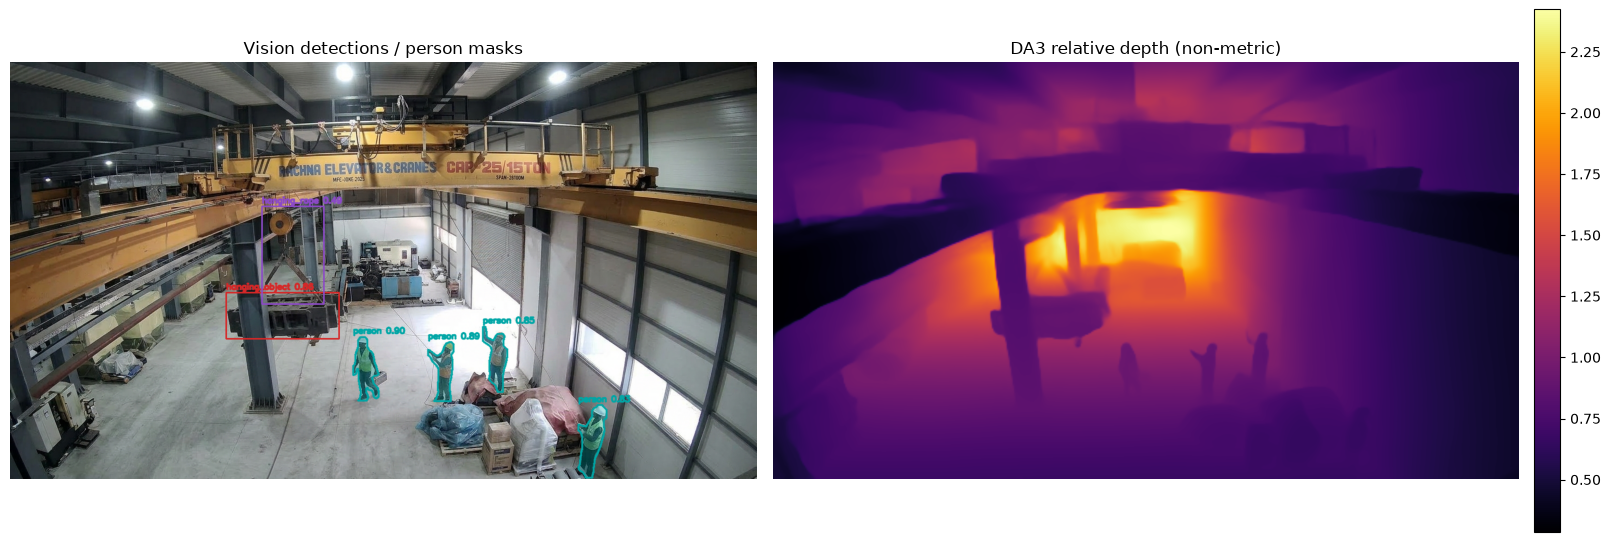

In [5]:
preview_bgr = render_detection_preview(image_bgr, vision_result.detections)
depth_map = vision_result.relative_depth.depth_map

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].imshow(cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Vision detections / person masks')
axes[0].axis('off')

depth_artist = axes[1].imshow(np.ma.masked_invalid(depth_map), cmap='inferno')
axes[1].set_title('DA3 relative depth (non-metric)')
axes[1].axis('off')
fig.colorbar(depth_artist, ax=axes[1], fraction=0.035, pad=0.02)
plt.show()

## 5. Chuyển kết quả Vision sang Geometry Engine

Không chạy depth model lại. Geometry dùng trực tiếp detections và `vision_result.relative_depth.depth_map`.

In [7]:
print(vision_result.detections)

[{'source_model': 'RF-DETR Medium', 'class_id': 0, 'class_name': 'hanging_object', 'confidence': 0.8556298017501831, 'bbox': (398.3682861328125, 424.17559814453125, 606.0258178710938, 509.04486083984375), 'x1': 398.3682861328125, 'y1': 424.17559814453125, 'x2': 606.0258178710938, 'y2': 509.04486083984375, 'mask': None}, {'source_model': 'RF-DETR Medium', 'class_id': 1, 'class_name': 'hanging_rope', 'confidence': 0.492591917514801, 'bbox': (463.6580810546875, 264.86834716796875, 578.3436889648438, 444.5063781738281), 'x1': 463.6580810546875, 'y1': 264.86834716796875, 'x2': 578.3436889648438, 'y2': 444.5063781738281, 'mask': None}, {'source_model': 'YOLO26m', 'class_id': 0, 'class_name': 'person', 'confidence': 0.9026564955711365, 'bbox': (631.7174682617188, 505.26055908203125, 679.7705688476562, 623.5214233398438), 'x1': 631.7174682617188, 'y1': 505.26055908203125, 'x2': 679.7705688476562, 'y2': 623.5214233398438, 'mask': array([[False, False, False, ..., False, False, False],
       [F

In [6]:
person_detections = [
    detection for detection in vision_result.detections
    if detection['class_name'] == 'person'
]
load_detections = [
    detection for detection in vision_result.detections
    if detection['class_name'] == 'hanging_object'
]

person_geometry = [
    {
        'object_id': f'person_{index:02d}',
        'detection': detection,
        'representative': estimate_person_representative(
            detection,
            depth_map,
            config=geometry_config.representative_depth,
        ),
    }
    for index, detection in enumerate(person_detections, start=1)
]

load_geometry = [
    {
        'object_id': f'hanging_object_{index:02d}',
        'detection': detection,
        'representative_depth': load_representative_depth(
            detection,
            depth_map,
            config=geometry_config.representative_depth,
        ),
    }
    for index, detection in enumerate(load_detections, start=1)
]

print(f'Geometry processed {len(person_geometry)} person(s) and {len(load_geometry)} load(s)')

Geometry processed 4 person(s) and 1 load(s)


## 6. Geometry result summary

In [8]:
geometry_summary = {
    'persons': [
        {
            'object_id': item['object_id'],
            **asdict(item['representative']),
        }
        for item in person_geometry
    ],
    'loads': [
        {
            'object_id': item['object_id'],
            **asdict(item['representative_depth']),
        }
        for item in load_geometry
    ],
}
geometry_summary

{'persons': [{'object_id': 'person_01',
   'point': {'x': 655.0, 'y': 615.0},
   'point_source': 'segmentation_bottom_band',
   'depth': {'value': 0.9167702794075012,
    'source': 'segmentation_mask:lower',
    'quality': 'high',
    'roi_statistics': {'full': {'valid_count': 3430,
      'mean': 0.9554491639137268,
      'median': 0.9234834909439087,
      'minimum': 0.8962101936340332,
      'maximum': 1.2598751783370972,
      'percentile_10': 0.9117728114128113,
      'percentile_90': 1.0491485595703125,
      'standard_deviation': 0.07822045683860779},
     'top': {'valid_count': 2197,
      'mean': 0.9756238460540771,
      'median': 0.9279240369796753,
      'minimum': 0.913374125957489,
      'maximum': 1.2598751783370972,
      'percentile_10': 0.9195265769958496,
      'percentile_90': 1.1259859323501586,
      'standard_deviation': 0.0911003053188324},
     'lower': {'valid_count': 1271,
      'mean': 0.9199212789535522,
      'median': 0.9167702794075012,
      'minimum': 0

## 7. Trực quan hóa kết quả Geometry trên ảnh và depth map

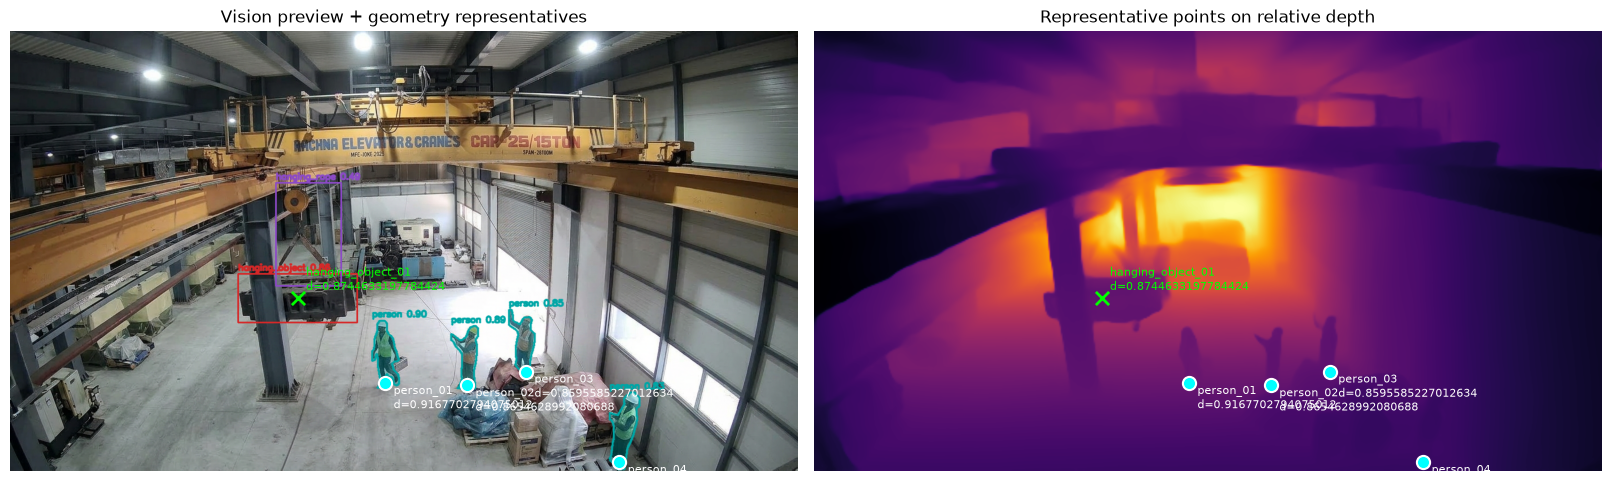

In [9]:
geometry_preview = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].imshow(geometry_preview)
axes[1].imshow(np.ma.masked_invalid(depth_map), cmap='inferno')

for item in person_geometry:
    result = item['representative']
    for axis in axes:
        axis.scatter(
            result.point.x, result.point.y,
            s=90, c='cyan', edgecolors='white', linewidths=1.5,
        )
        axis.annotate(
            f"{item['object_id']}\nd={result.depth.value}",
            (result.point.x, result.point.y), xytext=(6, -18),
            textcoords='offset points', color='white', fontsize=8,
        )

for item in load_geometry:
    detection = item['detection']
    result = item['representative_depth']
    x1, y1, x2, y2 = detection['bbox']
    center = ((x1 + x2) / 2.0, (y1 + y2) / 2.0)
    for axis in axes:
        axis.scatter(*center, s=90, c='lime', marker='x', linewidths=2)
        axis.annotate(
            f"{item['object_id']}\nd={result.value}",
            center, xytext=(6, 6), textcoords='offset points',
            color='lime', fontsize=8,
        )

axes[0].set_title('Vision preview + geometry representatives')
axes[1].set_title('Representative points on relative depth')
for axis in axes:
    axis.axis('off')
plt.show()

## 8. Sanity checks

Các assertion không bắt buộc ảnh phải có detection; chúng kiểm tra rằng mọi kết quả geometry được tạo đều hữu hạn hoặc được đánh dấu unavailable đúng contract.

In [10]:
assert depth_map.shape == image_bgr.shape[:2]
for item in person_geometry:
    result = item['representative']
    assert result.point_source in {
        'segmentation_bottom_band', 'segmentation_median', 'bbox_bottom_center'
    }
    assert result.depth.value is None or np.isfinite(result.depth.value)
for item in load_geometry:
    result = item['representative_depth']
    assert result.source in {'inner', 'full', 'unavailable'}
    assert result.value is None or np.isfinite(result.value)
print('Vision → Geometry checks passed')

Vision → Geometry checks passed
